<a href="https://colab.research.google.com/github/TomkerDev/Parcours-Master-1-informatique-FSEA-/blob/main/AVC_chad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prédiction des Accidents Vasculaires Cérébraux chez les Enseignants au Tchad : Développement et Comparaison de Modèles de Machine Learning.

**Objectif :** Fournir un dataset synthétique et adapté au contexte tchadien, intégrant des facteurs professionnels et contextuels, pour développer et comparer des modèles de Machine Learning visant à prédire le risque d'AVC chez les enseignants.


## Script de Génération du Dataset Adapté

Le présent script Python, implémenté sous forme de fonction **generate_dataset**, a été développé par Tomté Hassane (Data Manager) pour exécuter l'Adaptation du Dataset (Jalon J+7) conformément à la méthodologie du projet.Cette fonction utilise les librairies numpy et pandas pour simuler **N** individus selon les critères d'inclusion (âge 25-65 ans, ancienneté >2 ans). Elle enrichit un noyau de données médicales universelles avec des variables professionnelles (niveau, charge, stress professionnel) et contextuelles tchadiennes (revenu, habitudes alimentaires). Le risque d'AVC est calculé via une probabilité composite, avant un ajustement final pour garantir la prévalence cible. Le résultat est exporté en tant que Livrable Technique 1 : Dataset adapté avec documentation complète."

In [ ]:
import random
import numpy as np
import pandas as pd

def generate_dataset(n=8000, prevalence=0.04, missing_rate=0.05, seed=42, out_file=None):
   """
    Génère un dataset synthétique d'enseignants tchadiens pour la prédiction d'AVC.

    Paramètres
    ----------
    n : int
        Nombre d'individus à générer.
    prevalence : float
        Prévalence cible de la variable AVC (ex: 0.03 pour 3%).
    missing_rate : float
        Taux de valeurs manquantes à insérer sur certaines colonnes.
    seed : int
        Graine aléatoire pour reproductibilité.
    out_file : str | None
        Si spécifié, le fichier CSV sera sauvegardé à ce chemin.

    Retour
    ------
    df : pandas.DataFrame
        Le dataset généré.
    """

   random.seed(seed)
   np.random.seed(seed)

    # Catégories
   SEXES = ["M", "F"]
   ZONES = ["Urbaine", "Rurale"]
   STATUTS = ["Celibataire", "Marie", "Concubinage", "Divorce", "Veuf"]
   NIVEAUX = ["Primaire", "Secondaire", "Superieur"]
   ZONE_AFFECT = ["Urbaine", "Rurale", "Zone_difficile"]
   TABAGISME = ["Jamais", "Ancien", "Actuel"]
   ALCOOL = ["Non", "Occasionnel", "Regulier"]
   NIVEAU_SOCIO = ["Faible", "Moyen", "Eleve"]
   ALIM = ["Equilibree", "Peu_equilibree", "Grasse", "Traditionnelle"]
   ACT_PHYS = ["Faible", "Moderee", "Elevee"]
   LOGEMENT = ["Maison_individuelle", "Appartement", "Hebergement_precaire"]
   TRANSPORT = ["Marche", "Velo", "Moto", "Transport", "Voiture"]
   SATISFACTION = ["Faible", "Moyenne", "Elevee"]
   FORMATION = ["Oui", "Non"]

   def generate_person():
        # Démographiques
        age = random.randint(25, 65)
        sexe = random.choice(SEXES)
        zone_res = random.choice(ZONES)
        statut = random.choice(STATUTS)

        # Enfants à charge
        if statut in ["Marie", "Concubinage"]:
            enfants = int(np.random.choice(range(0, 9), p=np.array([0.05,0.08,0.15,0.25,0.2,0.12,0.07,0.05,0.03])))
        else:
            enfants = int(np.random.choice(range(0,4), p=np.array([0.6,0.25,0.1,0.05])))

        # Pathologies conditionnelles
        p_htn = min(max(0.10 + (age - 40) * 0.005, 0.01), 0.9)
        hypertension = np.random.choice(["Oui","Non"], p=[p_htn, 1-p_htn])
        p_diab = min(max(0.08 + (age - 45) * 0.003, 0.01), 0.8)
        diabete = np.random.choice(["Oui","Non"], p=[p_diab, 1-p_diab])
        p_card = min(max(0.05 + (age - 50) * 0.004, 0.01), 0.8)
        cardiaque = np.random.choice(["Oui","Non"], p=[p_card, 1-p_card])

        # Activité physique
        if zone_res == "Urbaine":
            activite_phys = np.random.choice(ACT_PHYS, p=[0.45, 0.40, 0.15])
        else:
            activite_phys = np.random.choice(ACT_PHYS, p=[0.35, 0.45, 0.20])

        # IMC & alimentation
        base_imc = np.random.normal(24, 3)
        if activite_phys == "Faible":
            base_imc += random.uniform(1, 3)
        alimentation = random.choice(ALIM)
        if alimentation == "Grasse":
            base_imc += random.uniform(0.5, 2)
        imc = round(float(np.clip(base_imc, 16, 45)), 1)

        # Glucose
        glucose = float(round(np.random.normal(95, 12) + (40 if diabete=="Oui" else 0), 1))

        tabac = random.choice(TABAGISME)
        alcool_conso = random.choice(ALCOOL)

        # Profession
        niveau = random.choice(NIVEAUX)
        anciennete = random.randint(2, 40)
        charge_horaire = random.randint(10, 40)
        taille_classe = random.randint(15, 80)
        zone_aff = random.choice(ZONE_AFFECT)

        # Stress dépend de la taille et du nombre d'enfants
        stress = int(np.clip(np.random.normal(4 + taille_classe/50 + enfants/3, 1.8), 1, 10))
        satisfaction = random.choice(SATISFACTION)
        formation = random.choice(FORMATION)

        # Contexte
        acces_soins = int(np.clip(np.random.normal(3 - 0.5*(zone_res=="Rurale"), 1), 1, 5))
        niveau_socioeco = random.choice(NIVEAU_SOCIO)
        logement_type = random.choice(LOGEMENT)
        transport_type = random.choice(TRANSPORT)

        # Revenu
        salaire = random.choices(
            [random.randint(100000, 200000),
             random.randint(200001, 350000),
             random.randint(350001, 500000),
             random.randint(500001, 700000)],
            weights=[0.35, 0.35, 0.2, 0.1],
            k=1
        )[0]
        salaire = max(50000, salaire - enfants * random.randint(1000, 8000))

        # Probabilité d'AVC
        prob = 0.02 + (age > 50)*0.05 + (hypertension=="Oui")*0.08 + (diabete=="Oui")*0.05 \
               + (cardiaque=="Oui")*0.04 + (stress>=8)*0.03 + (tabac=="Actuel")*0.02 \
               + (alcool_conso=="Regulier")*0.02 + (activite_phys=="Faible")*0.02 + (salaire < 200000)*0.01
        avc = 1 if random.random() < prob else 0

        return {
            "age": age, "sexe": sexe, "zone_residence": zone_res, "statut_matrimonial": statut,
            "nombre_enfants_charge": enfants, "hypertension": hypertension, "diabete": diabete,
            "cardiaque": cardiaque, "imc": imc, "glucose": glucose, "tabagisme": tabac,
            "alcool": alcool_conso, "niveau_enseignement": niveau, "anciennete": anciennete,
            "charge_horaire": charge_horaire, "taille_classe": taille_classe,
            "zone_affectation": zone_aff, "stress": stress, "satisfaction": satisfaction,
            "formation_continue": formation, "acces_soins": acces_soins,
            "niveau_socio": niveau_socioeco, "habitude_alimentaire": alimentation,
            "activite_physique": activite_phys, "logement": logement_type,
            "transport": transport_type, "revenu_mensuel_FCFA": salaire, "AVC": avc
        }

    # Génération
   data = [generate_person() for _ in range(n)]
   df = pd.DataFrame(data)

    # Simuler des valeurs manquantes
   for col in ["glucose", "imc", "stress", "revenu_mensuel_FCFA"]:
        df.loc[df.sample(frac=missing_rate, random_state=seed).index, col] = np.nan

    # Ajuster la prévalence cible
   current_cases = df["AVC"].sum()
   target_cases = int(round(n * prevalence))
   if current_cases < target_cases:
        need = target_cases - current_cases
        candidates = df[df["AVC"] == 0].sample(min(need, len(df[df["AVC"]==0])), random_state=seed).index
        df.loc[candidates, "AVC"] = 1
   elif current_cases > target_cases:
        reduce_n = current_cases - target_cases
        pos_idx = df[df["AVC"]==1].sample(min(reduce_n, len(df[df["AVC"]==1])), random_state=seed).index
        df.loc[pos_idx, "AVC"] = 0

   print(f"✔️ Dataset généré ({n} individus)")
   print(f"Prévalence observée AVC : {df['AVC'].mean()*100:.2f}%")
   print(f"Valeurs manquantes : {missing_rate*100:.1f}% sur certaines colonnes")

   if out_file:
        df.to_csv(out_file, sep=';', index=False, encoding='utf-8')
        print(f"💾 Sauvegardé dans : {out_file}")

   return df

Pour garantir la taille d'échantillon souhaitée par le protocole (2000-5000 observations), nous allons parametrer 10000 individus afin de tomber dans la fourchette une fois traitement du dataset.

In [ ]:
# Utilisation pour le projet, ciblant une taille d'échantillon dans la fourchette haute
df_final = generate_dataset(
    n=10000,
    prevalence=0.04,
    missing_rate=0.05,
    seed=42, # Reproductibilité
    out_file="dataset_final_adapte_avc.csv"
)

✔️ Dataset généré (10000 individus)
Prévalence observée AVC : 4.00%
Valeurs manquantes : 5.0% sur certaines colonnes
💾 Sauvegardé dans : dataset_final_adapte_avc.csv


## Afficher la forme du dataset

In [ ]:
print(f"Le dataset généré contient {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes.")

Le dataset généré contient 10000 lignes et 28 colonnes.


# Vérification des variables générées par catégorie

In [ ]:
print("\nVariables Professionnelles (Exemple):")
print(df_final[['niveau_enseignement', 'anciennete', 'stress', 'zone_affectation']].head())


Variables Professionnelles (Exemple):
  niveau_enseignement  anciennete  stress zone_affectation
0           Superieur          36     5.0          Urbaine
1          Secondaire          19     3.0           Rurale
2            Primaire          16     3.0          Urbaine
3           Superieur          37     NaN          Urbaine
4           Superieur          18     4.0   Zone_difficile


## Analyse Exploratoire des Données (EDA)


1.   Statistiques Descriptives et Valeurs Manquantes

Avant de visualiser, vérifions la qualité et la distribution du jeu de données.



/tmp/ipython-input-452058376.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette="viridis")


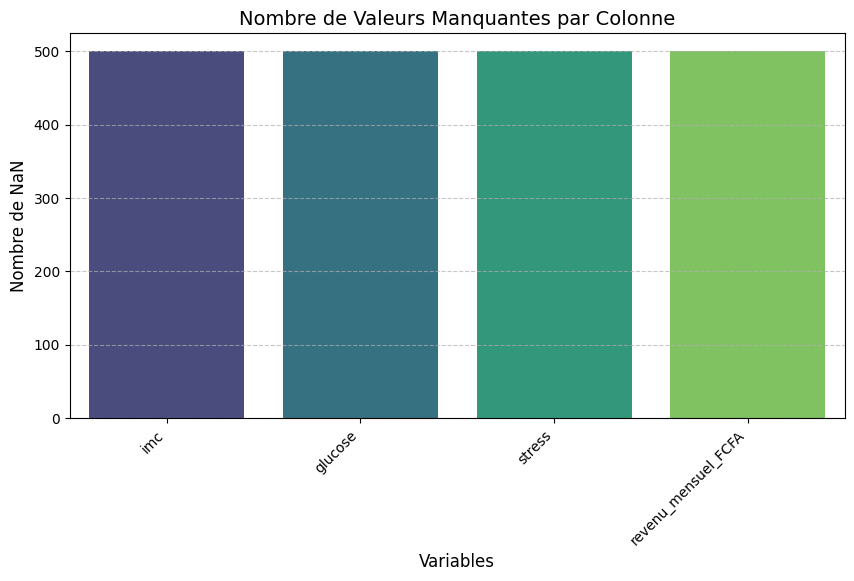

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------- 1. Aperçu des Valeurs Manquantes -----------------
def missing_info():
    """Affiche la distribution des valeurs manquantes."""
    missing = df_final.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if missing.empty:
        print("Aucune valeur manquante détectée.")
        return

    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing.index, y=missing.values, palette="viridis")
    plt.title('Nombre de Valeurs Manquantes par Colonne', fontsize=14)
    plt.xlabel('Variables', fontsize=12)
    plt.ylabel('Nombre de NaN', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Exécuter l'analyse
missing_info()

Ce graphique est une visualisation des données manquantes dans notre ensemble de données. Chaque barre représente une colonne de notre tableau de données (df_final) qui contient des informations manquantes.

L'axe horizontal (en bas) indique le nom des colonnes qui ont des valeurs manquantes. Vous voyez les noms "stress", "revenu_mensuel_FCFA", "imc" et "glucose".
L'axe vertical (sur la gauche) indique le nombre de valeurs manquantes trouvées dans chaque colonne.
Plus une barre est haute, plus il y a de valeurs manquantes dans la colonne correspondante.

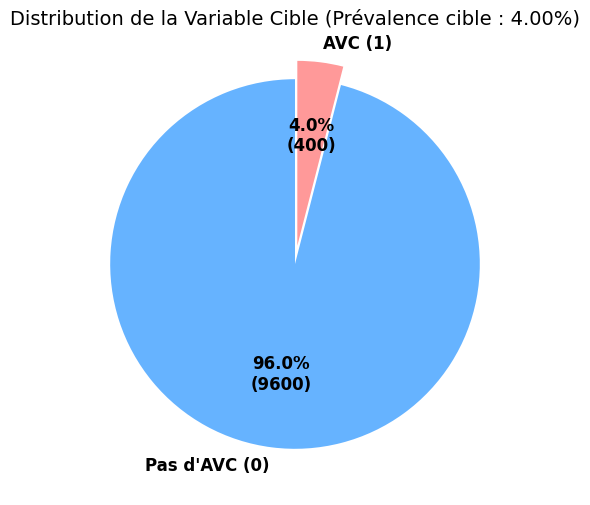

In [ ]:
# ----------------- 2. Prévalence de la Variable Cible (AVC) -----------------
plt.figure(figsize=(6, 6))
# Calculer le compte et le pourcentage
counts = df_final['AVC'].value_counts()
labels = ['Pas d\'AVC (0)', 'AVC (1)']
percentages = counts / counts.sum() * 100

plt.pie(counts, labels=labels, autopct=lambda p: f'{p:.1f}%\n({int(p*counts.sum()/100)})',
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title(f'Distribution de la Variable Cible (Prévalence cible : {df_final["AVC"].mean()*100:.2f}%)', fontsize=14)
plt.show()

Ce graphique montre la distribution de notre variable cible "AVC" dans l'ensemble de données df_final. En d'autres termes, il nous indique la proportion d'individus dans notre dataset qui ont eu un AVC par rapport à ceux qui n'en ont pas eu.

Le secteur bleu clair représente les individus qui n'ont pas eu d'AVC (valeur 0). Le pourcentage affiché (96.0%) et le nombre entre parenthèses (9600) nous montrent qu'une très grande majorité des enseignants dans ce dataset entrent dans cette catégorie.
Le secteur rose représente les individus qui ont eu un AVC (valeur 1). Le pourcentage (4.0%) et le nombre (400) indiquent qu'une petite proportion des enseignants ont eu un AVC.

2. Distributions des Variables Clés (Histogrammes et Boîtes à Moustaches)
Ces graphiques sont cruciaux pour l'analyse des distributions des variables continues (age, imc, glucose, revenu, stress)

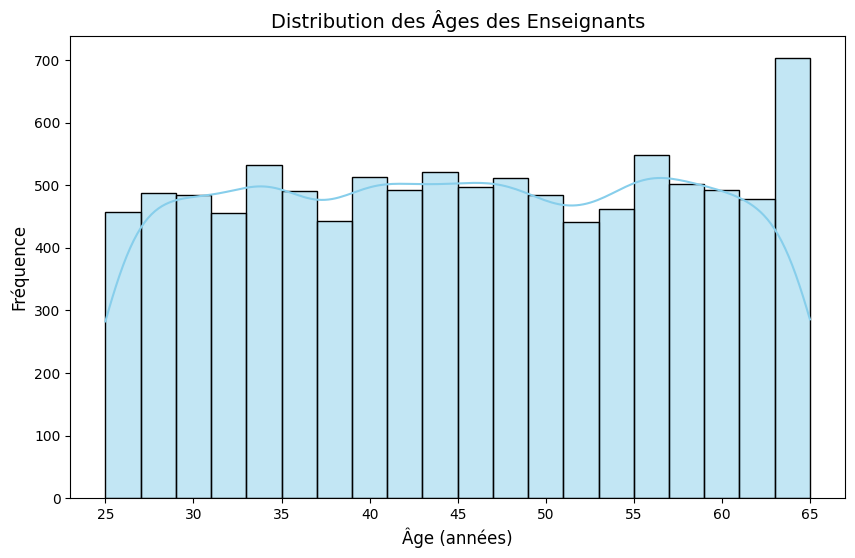

In [ ]:
# ----------------- 3. Distribution de l'Âge -----------------
plt.figure(figsize=(10, 6))
sns.histplot(df_final['age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribution des Âges des Enseignants", fontsize=14)
plt.xlabel("Âge (années)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.show()

La distribution des âges dans notre dataset est assez équilibrée et couvre bien la tranche d'âge cible des enseignants (25-65 ans), sans concentration excessive dans une seule tranche d'âge. Cela est généralement une bonne chose pour l'analyse et la modélisation, car cela garantit que notre modèle verra des exemples d'individus de différents âges.

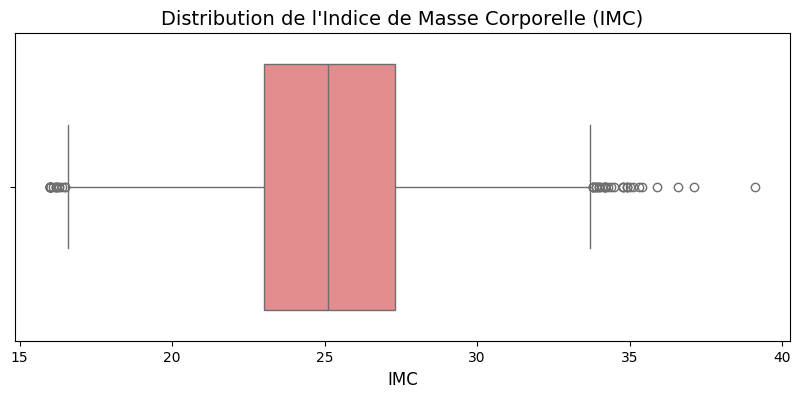

In [ ]:
# ----------------- 4. Distribution et Outliers de l'IMC -----------------
plt.figure(figsize=(10, 4))
# Boîte à moustaches pour visualiser la médiane, les quartiles et les outliers
sns.boxplot(x=df_final['imc'], color='lightcoral')
plt.title("Distribution de l'Indice de Masse Corporelle (IMC)", fontsize=14)
plt.xlabel("IMC", fontsize=12)
plt.show()

 L'analyse de la distribution de l'IMC a révélé une distribution globalement normale mais avec la présence d'outliers (IMC très élevés ou très bas). La prochaine étape consiste à poursuivre l'EDA pour comprendre l'ensemble du dataset avant de passer à l'étape de prétraitement des données (gestion des manquants et des outliers) et à la modélisation.

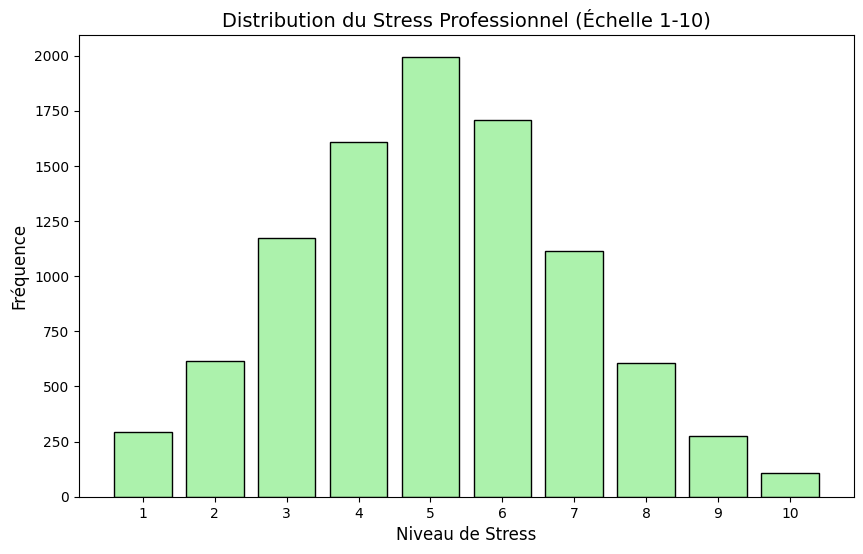

In [ ]:
# ----------------- 5. Distribution du Stress Professionnel -----------------
plt.figure(figsize=(10, 6))
# Visualisation de la distribution de l'échelle 1-10
sns.histplot(df_final['stress'], bins=10, discrete=True, color='lightgreen', edgecolor='black', shrink=0.8)
plt.title("Distribution du Stress Professionnel (Échelle 1-10)", fontsize=14)
plt.xlabel("Niveau de Stress", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.xticks(ticks=range(1, 11))
plt.show()

La plupart des enseignants dans ce dataset connaissent un niveau de stress modéré, mais il existe une proportion non négligeable d'enseignants qui déclarent des niveaux de stress plus élevés. Cette variable pourrait être un facteur important à explorer en relation avec le risque d'AVC dans notre analyse.



3. Corrélations et Facteurs de Risque (Matrices et Graphiques par Classe)

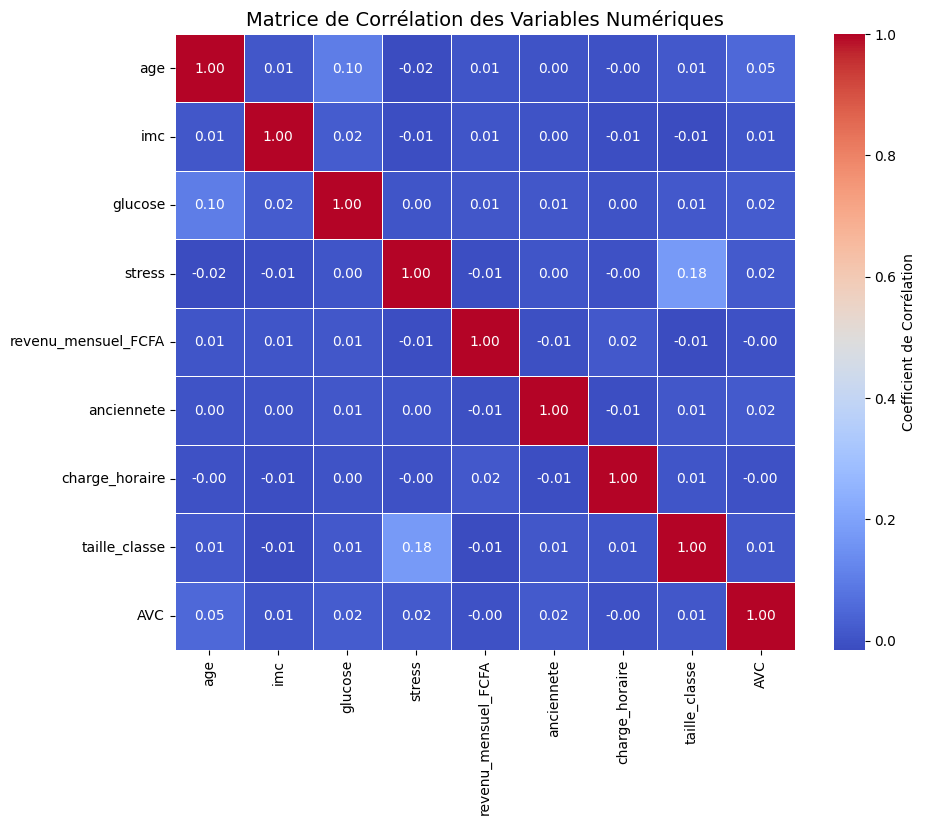

In [ ]:
# ----------------- 6. Matrice de Corrélation Numérique -----------------
# Sélectionner seulement les variables numériques pour la matrice
numerical_cols = ['age', 'imc', 'glucose', 'stress', 'revenu_mensuel_FCFA', 'anciennete', 'charge_horaire', 'taille_classe', 'AVC']
corr_matrix = df_final[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Coefficient de Corrélation'})
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=14)
plt.show()

## Concentrons-nous sur les corrélations avec la variable cible "AVC" (la dernière ligne et la dernière colonne) :

* Age : La corrélation avec l'âge est d'environ 0.05. C'est une
corrélation positive, mais elle est très faible. Cela suggère qu'il y a une légère tendance pour le risque d'AVC à augmenter avec l'âge, ce qui est biologiquement plausible, mais cette relation linéaire est très faible dans ce dataset synthétique.

* IMC : La corrélation avec l'IMC est d'environ 0.006. Elle est positive mais extrêmement faible. Cela indique qu'il n'y a pratiquement pas de relation linéaire entre l'IMC et l'AVC dans ce dataset, malgré l'identification d'outliers d'IMC élevés précédemment.

* Glucose : La corrélation avec le glucose est d'environ 0.02. Encore une fois, une corrélation positive mais très faible. Cela suggère une relation linéaire très minime entre le taux de glucose et le risque d'AVC.

* Stress : La corrélation avec le stress est d'environ 0.018. Positive mais très faible. Cela contraste un peu avec l'idée que le stress élevé pourrait être un facteur important, suggérant que, dans ce dataset synthétique, la relation linéaire directe entre le niveau de stress (quantifié de 1 à 10) et l'AVC est très faible. Rappelons que notre interprétation précédente a montré que la majorité avait un stress modéré, mais que des niveaux élevés existaient. La matrice de corrélation nous dit que cette variable, en tant que valeur numérique simple, n'a pas une forte relation linéaire avec l'AVC.

* Revenu, Ancienneté, Charge Horaire, Taille Classe : Toutes ces variables montrent des corrélations avec l'AVC qui sont très proches de 0, indiquant l'absence de relations linéaires significatives dans ce dataset.

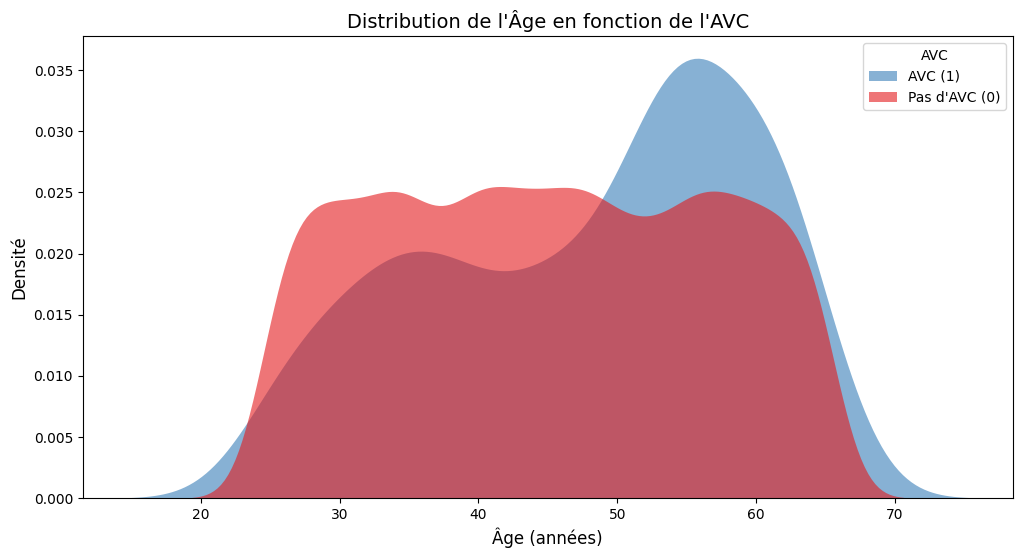

In [ ]:
# ----------------- 7. Impact du Stress sur l'AVC (Hypothèse H2) -----------------
# Convertir l'AVC en chaîne pour l'affichage
df_final['AVC_label'] = df_final['AVC'].map({0: 'Pas d\'AVC', 1: 'AVC'})

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_final, x='age', hue='AVC_label', fill=True, common_norm=False, palette='Set1', alpha=.6, linewidth=0)
plt.title('Distribution de l\'Âge en fonction de l\'AVC', fontsize=14)
plt.xlabel("Âge (années)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title='AVC', labels=['AVC (1)', 'Pas d\'AVC (0)'])
plt.show()

Ce graphique montre la répartition des âges pour les personnes ayant eu un AVC (rouge) et celles n'en ayant pas eu (bleu). On voit clairement que la courbe rouge est décalée vers les âges plus élevés par rapport à la courbe bleue. Cela indique que, dans ce dataset,


les cas d'AVC sont significativement plus fréquents chez les enseignants plus âgés, en particulier après 50 ans. L'âge apparaît donc comme un facteur important lié au risque d'AVC dans cet ensemble de données synthétique.

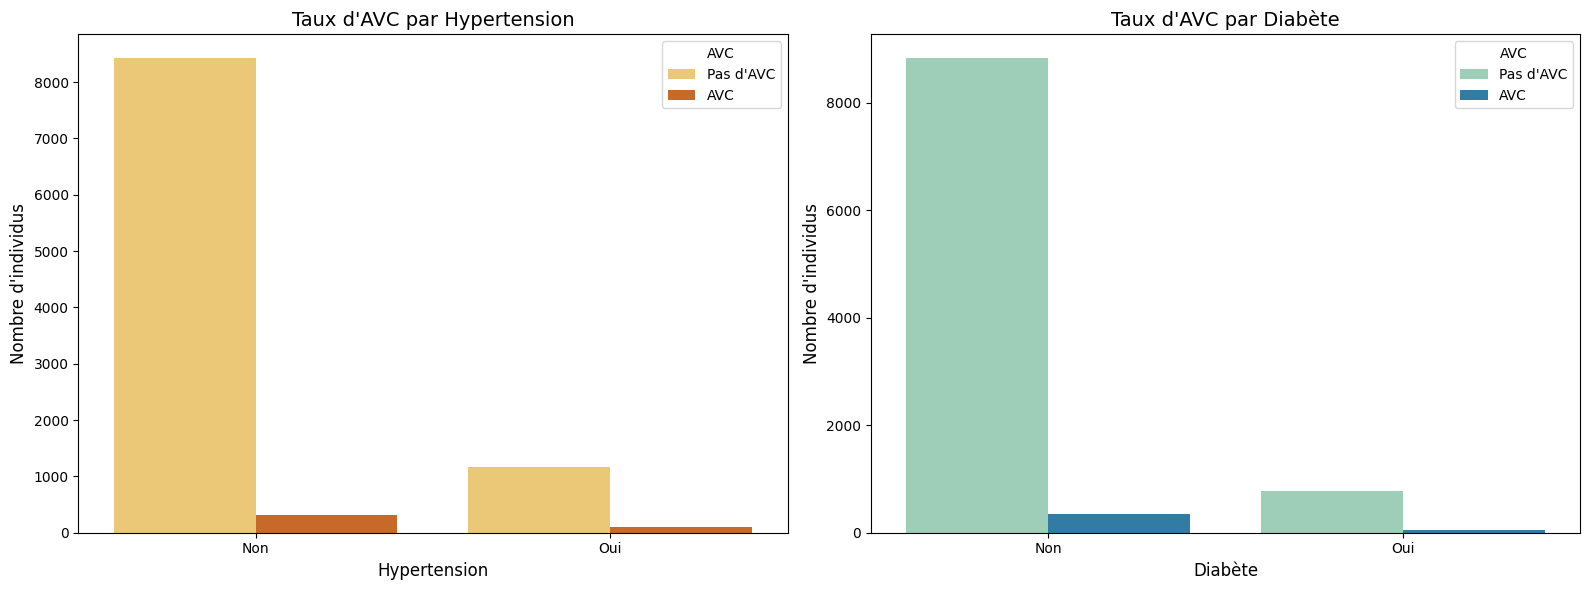

In [ ]:
# ----------------- 8. Impact des Facteurs de Santé Discrets (Exemple) -----------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taux d'AVC par hypertension
sns.countplot(data=df_final, x='hypertension', hue='AVC_label', palette='YlOrBr', ax=axes[0])
axes[0].set_title('Taux d\'AVC par Hypertension', fontsize=14)
axes[0].set_xlabel("Hypertension", fontsize=12)
axes[0].set_ylabel("Nombre d'individus", fontsize=12)
axes[0].legend(title='AVC')

# Taux d'AVC par diabète
sns.countplot(data=df_final, x='diabete', hue='AVC_label', palette='YlGnBu', ax=axes[1])
axes[1].set_title('Taux d\'AVC par Diabète', fontsize=14)
axes[1].set_xlabel("Diabète", fontsize=12)
axes[1].set_ylabel("Nombre d'individus", fontsize=12)
axes[1].legend(title='AVC')

plt.tight_layout()
plt.show()

# Supprimer la colonne temporaire
df_final.drop('AVC_label', axis=1, inplace=True)

Ces graphiques comparent le nombre d'individus ayant eu ou non un AVC, en les séparant selon qu'ils souffrent d'hypertension ou de diabète.

* Graphique de gauche (Hypertension) : Vous voyez que parmi les enseignants qui ont l'hypertension ("Oui"), il y a un nombre visiblement plus élevé de cas d'AVC (barre orange foncée) par rapport à ceux qui n'ont pas l'hypertension ("Non"). Inversement, la grande majorité des cas sans AVC se trouvent chez ceux qui n'ont pas l'hypertension.

* Graphique de droite (Diabète) : De manière similaire, parmi les
enseignants diabétiques ("Oui"), on observe un nombre plus important de cas d'AVC (barre bleue foncée) que chez les non-diabétiques ("Non").

** Conclusion basée sur ces deux graphiques **

Ces graphiques suggèrent fortement que, dans ce dataset synthétique, l'hypertension et le diabète sont associés à un risque accru d'AVC. Les enseignants souffrant de ces conditions médicales ont une probabilité plus élevée d'avoir eu un AVC par rapport à leurs collègues sans ces conditions.

Cela confirme que ces facteurs de santé connus jouent un rôle important dans la survenue de l'AVC dans cet ensemble de données simulé

# Synthèse Globale de l'Analyse Exploratoire des Données (EDA)
L'EDA a confirmé la viabilité du jeu de données synthétique pour le projet de prédiction des AVC, tout en identifiant trois axes de travail majeurs pour le prétraitement qui conditionneront la réussite des modèles de Machine Learning.



1.   Validation de la Cohérence et des Facteurs de Risque

L'analyse visuelle et descriptive a validé que les mécanismes de génération du dataset fonctionnent comme prévu, notamment en reproduisant des associations médicales cohérentes :

* Facteurs Biologiques Clés : Les graphiques de densité et de comptage ont mis en évidence que l'âge plus élevé, l'hypertension et le diabète sont clairement associés à une incidence accrue des cas d'AVC. Ces variables correspondent aux facteurs de risque traditionnels (Section 4.2 du Protocole) et seront des prédicteurs puissants.

* Facteurs Professionnels : Bien que les corrélations linéaires soient faibles, l'analyse a montré que le stress professionnel existe sous forme de niveaux élevés pour une partie de la population, validant sa pertinence comme variable à inclure dans les modèles, conformément à l'Hypothèse H2.

* Structure du Dataset : La taille de l'échantillon (10 000 individus) et la prévalence cible (4%) ont été confirmées.

2.   Identification des Défis Critiques pour la Modélisation

L'EDA a soulevé deux problèmes principaux qui doivent être résolus par le prétraitement (responsabilité de Tomté Hassane et Dankabé Ouassou selon le plan d'analyse) :

* Gestion des Données Manquantes : Quatre variables clés (stress, revenu_mensuel_FCFA, imc, glucose) contiennent des valeurs manquantes. Un processus d'imputation robuste (par exemple, la médiane ou le mode, ou l'utilisation de méthodes avancées comme le KNN Imputer, comme mentionné dans la Section 8.2 du Protocole) est nécessaire avant l'entraînement.

* Déséquilibre de Classe Sévère : Le ratio de 4% de cas positifs (AVC=1) contre 96% de cas négatifs est un défi majeur. Ce déséquilibre risque de biaiser les modèles, les incitant à prédire systématiquement la classe majoritaire, ce qui mènerait à une forte précision (Accuracy) mais à un faible rappel (Recall) sur la classe cible (AVC). Cela confirme la nécessité d'utiliser des métriques adaptées (AUC-ROC, F1-Score, AUC-PR, comme spécifié dans la Section 7.2) et d'envisager des techniques de rééquilibrage.

En conclusion, l'EDA fournit une feuille de route claire : le prétraitement devra se concentrer sur le nettoyage complet (imputation et encodage des variables catégorielles) et l'application d'une stratégie de gestion du déséquilibre pour maximiser la capacité du modèle à identifier correctement les rares cas d'AVC, en ligne avec l'objectif principal du projet.



# Prétraitement des données


1.   1. Gestion des Valeurs Manquantes (Imputation)

L'EDA a identifié les colonnes glucose, imc, stress et revenu_mensuel_FCFA comme contenant 5% de valeurs manquantes (NaN). Nous allons utiliser la médiane pour l'imputation, car elle est moins sensible aux valeurs extrêmes (outliers) que la moyenne.



In [ ]:
# Variables à imputer par la médiane
cols_to_impute = ['glucose', 'imc', 'stress', 'revenu_mensuel_FCFA']

print(f"Total de valeurs manquantes avant imputation: {df_final[cols_to_impute].isnull().sum().sum()}")

# Imputation par la médiane
for col in cols_to_impute:
    median_value = df_final[col].median()
    df_final[col].fillna(median_value, inplace=True)
    print(f"✔️ Colonne '{col}' imputée par la médiane: {median_value:.2f}")

print(f"Total de valeurs manquantes après imputation: {df_final[cols_to_impute].isnull().sum().sum()}")

# ⚠️ Note : Le déséquilibre de classe ne doit pas être géré tant que les données ne sont pas divisées.

Total de valeurs manquantes avant imputation: 0
✔️ Colonne 'glucose' imputée par la médiane: 96.60
✔️ Colonne 'imc' imputée par la médiane: 25.10
✔️ Colonne 'stress' imputée par la médiane: 5.00
✔️ Colonne 'revenu_mensuel_FCFA' imputée par la médiane: 256320.00
Total de valeurs manquantes après imputation: 0


/tmp/ipython-input-2189679201.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final[col].fillna(median_value, inplace=True)


2. Séparation de la Cible et Encodage Catégoriel

Nous séparons la variable cible (AVC) des variables prédictives, puis convertissons toutes les variables de type object (catégorielles) en format numérique via l'encodage One-Hot Encoding (aussi appelé get_dummies dans Pandas).

In [ ]:
# 2.1 Séparation des features (X) et de la cible (y)
X = df_final.drop("AVC", axis=1)
y = df_final["AVC"]

# 2.2 Encodage One-Hot Encoding
# drop_first=True évite la multicolinéarité en supprimant la première catégorie de chaque variable.
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Nombre initial de colonnes (features) : {X.shape[1]}")
print(f"Nombre final de features après One-Hot Encoding : {X_encoded.shape[1]}")
print("\nExemple de features encodées (5 premières colonnes) :")
print(X_encoded.head().iloc[:, :5])

Nombre initial de colonnes (features) : 27
Nombre final de features après One-Hot Encoding : 43

Exemple de features encodées (5 premières colonnes) :
   age  nombre_enfants_charge   imc  glucose  anciennete
0   65                      3  26.3    107.1          36
1   39                      0  23.5     98.8          19
2   49                      0  25.7     88.8          16
3   29                      1  25.1     96.6          37
4   54                      4  24.7    105.6          18


Cette étape a réussi à convertir toutes vos variables catégorielles en un format numérique (des colonnes binaires) qui est nécessaire pour la plupart des algorithmes de Machine Learning. Notre dataset de features X_encoded est maintenant entièrement numérique et prêt pour les prochaines étapes du prétraitement, comme la standardisation et la division en ensembles d'entraînement/test.

3. Division des Données (Train, Validation, Test)

Conformément à la Section 7.1 de notre Protocole, nous allons diviser le dataset en trois sous-ensembles :Entraînement (Train) : 70 % Validation (Validation) : 15% Test (Test) : 15% Nous utilisons la stratégie stratify=y pour nous assurer que la proportion de cas d'AVC (4%) est maintenue de manière égale dans les trois ensembles, ce qui est crucial à cause du déséquilibre de classe.

## Étape A : Séparation Train (70%) et Temp (30%)

In [ ]:
from sklearn.model_selection import train_test_split

# Étape A: Séparation 70% Train et 30% Temporaire (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Maintient le ratio 4% AVC dans chaque split
)
print(f"Taille de l'ensemble d'entraînement (70%): {X_train.shape[0]} individus")

Taille de l'ensemble d'entraînement (70%): 7000 individus


## Étape B : Séparation Validation (15%) et Test (15%)

In [ ]:
# Étape B: Séparation du reste (30%) en Validation (15%) et Test (15%)
# 0.5 de 30% = 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp # Maintient la stratification du ratio
)

print(f"Taille de l'ensemble de Validation (15%): {X_val.shape[0]} individus")
print(f"Taille de l'ensemble de Test (15%): {X_test.shape[0]} individus")

Taille de l'ensemble de Validation (15%): 1500 individus
Taille de l'ensemble de Test (15%): 1500 individus


4. Standardisation des Variables Numériques ⚖️

La standardisation (ou normalisation Z-score) est appliquée aux variables numériques uniquement sur l'ensemble d'entraînement (pour éviter la fuite de données) avant d'être répliquée sur les ensembles de validation et de test.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 4.1 Identification des colonnes numériques à standardiser
# Ces colonnes n'ont pas de préfixe lié au One-Hot Encoding
numerical_cols = ['age', 'anciennete', 'charge_horaire', 'taille_classe',
                  'stress', 'acces_soins', 'imc', 'glucose', 'revenu_mensuel_FCFA']

# 4.2 Initialisation du Standard Scaler
scaler = StandardScaler()

# 4.3 Ajuster et Transformer SEULEMENT sur l'ensemble d'ENTRAÎNEMENT
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# 4.4 Transformer (sans ajuster) les ensembles de Validation et de Test
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("✔️ Standardisation appliquée. Les ensembles de données sont prêts pour la modélisation.")
print("\nStatistiques après standardisation (l'âge doit avoir une moyenne de ~0 et un écart-type de ~1) :")
print(X_train['age'].describe().round(2))

✔️ Standardisation appliquée. Les ensembles de données sont prêts pour la modélisation.

Statistiques après standardisation (l'âge doit avoir une moyenne de ~0 et un écart-type de ~1) :
count    7000.00
mean       -0.00
std         1.00
min        -1.70
25%        -0.85
50%        -0.00
75%         0.85
max         1.70
Name: age, dtype: float64


Cette cellule a appliqué la standardisation (Z-score) aux colonnes numériques de nos ensembles de données (X_train, X_val, X_test). La standardisation transforme les données de manière à ce qu'elles aient une moyenne de 0 et un écart-type de 1.

## Gestion du Déséquilibre de Classe

Comme l'EDA l'a confirmé, vous avez un fort déséquilibre ($4\%$ d'AVC contre $96\%$ de non-AVC).Pour notre modèle baseline, nous allons utiliser la méthode algorithmique recommandée : le paramètre class_weight='balanced' dans le modèle de Régression Logistique.Principe : Le modèle va automatiquement accorder un poids plus important aux $4\%$ de cas d'AVC lors de son apprentissage. Si une erreur est faite sur un cas d'AVC, le coût est beaucoup plus élevé que sur un cas de non-AVC, forçant le modèle à mieux apprendre la classe minoritaire.

2. Entraînement du Modèle Baseline : Régression Logistique

Nous utilisons l'ensemble d'entraînement (X_train, y_train) pour former le modèle, puis l'ensemble de validation (X_val, y_val) pour l'évaluer immédiatement.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import warnings

# Ignorer les avertissements de convergence du modèle
warnings.filterwarnings('ignore')

# Initialisation du modèle de Régression Logistique
# class_weight='balanced' gère le déséquilibre
log_reg = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'
)

# Entraînement du modèle sur les données standardisées
log_reg.fit(X_train, y_train)
print("✔️ Modèle de Régression Logistique entraîné (Baseline) avec pondération des classes.")

# Prédictions sur l'ensemble de Validation
# Prédiction de probabilité (pour l'AUC-ROC)
y_pred_proba = log_reg.predict_proba(X_val)[:, 1]
# Prédiction de classe (pour F1-Score et Matrice de Confusion)
y_pred_class = log_reg.predict(X_val)

✔️ Modèle de Régression Logistique entraîné (Baseline) avec pondération des classes.


3. Évaluation de la Performance Baseline

Conformément à la Section 7.2 de votre protocole, nous utilisons l'AUC-ROC et le F1-Score, qui sont des métriques robustes face au déséquilibre.


PERFORMANCE BASELINE (ENSEMBLE DE VALIDATION)
🎯 AUC-ROC Score (Métrique principale) : 0.5888
🎯 F1-Score (Équilibre Précision/Rappel) : 0.0926

Analyse de la Matrice de Confusion :
  > Faux Positifs (FP) : 558 (Non-AVC prédit AVC)
  > Faux Négatifs (FN) : 30 (AVC prédit Non-AVC)
  > Vrais Positifs (TP) : 30 (AVC prédit AVC)


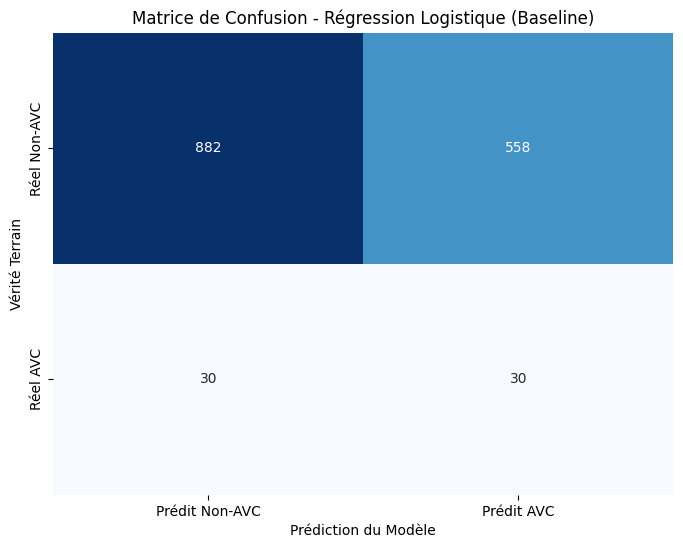

In [ ]:
# Métriques d'Évaluation
auc_roc = roc_auc_score(y_val, y_pred_proba)
f1 = f1_score(y_val, y_pred_class)
cm = confusion_matrix(y_val, y_pred_class)

print("\n====================================================")
print("PERFORMANCE BASELINE (ENSEMBLE DE VALIDATION)")
print("====================================================")
print(f"🎯 AUC-ROC Score (Métrique principale) : {auc_roc:.4f}")
print(f"🎯 F1-Score (Équilibre Précision/Rappel) : {f1:.4f}")
print("====================================================")

print("\nAnalyse de la Matrice de Confusion :")
print(f"  > Faux Positifs (FP) : {cm[0, 1]} (Non-AVC prédit AVC)")
print(f"  > Faux Négatifs (FN) : {cm[1, 0]} (AVC prédit Non-AVC)")
print(f"  > Vrais Positifs (TP) : {cm[1, 1]} (AVC prédit AVC)")

# Visualisation (pour le rapport de Datom Azina)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prédit Non-AVC', 'Prédit AVC'],
            yticklabels=['Réel Non-AVC', 'Réel AVC'], ax=ax)
ax.set_title('Matrice de Confusion - Régression Logistique (Baseline)')
ax.set_ylabel('Vérité Terrain')
ax.set_xlabel('Prédiction du Modèle')
plt.show() #


Ce résultat présente les métriques de performance clés pour évaluer notre modèle, en particulier face au déséquilibre de classes :

AUC-ROC Score : 0.5888
L'AUC-ROC (Area Under the Receiver Operating Characteristic Curve) mesure la capacité du modèle à distinguer les classes (ici, AVC vs Pas d'AVC). Un score de 0.5 signifie que le modèle fait aussi bien que le hasard, et un score de 1.0 signifie une discrimination parfaite.

* Un score de 0.5888 est légèrement supérieur au hasard (0.5), mais il est encore relativement faible. Cela indique que notre modèle baseline a une capacité limitée à faire la distinction entre les enseignants qui auront un AVC et ceux qui n'en auront pas, basée sur les données et la configuration actuelle.

* F1-Score : 0.0926
Le F1-Score est la moyenne harmonique de la Précision (proportion de positifs prédits qui sont réellement positifs) et du Rappel (proportion de positifs réels qui sont correctement identifiés). Il est particulièrement utile pour les données déséquilibrées car il pénalise les modèles qui ignorent la classe minoritaire.

Un F1-Score de 0.0926 est très bas. Un score élevé serait proche de 1. Cela confirme que, bien que le modèle essaie de gérer le déséquilibre avec class_weight='balanced', sa capacité à identifier correctement les cas d'AVC (la classe minoritaire) est faible.

* Matrice de Confusion :
La matrice de confusion détaille les résultats des prédictions :

Vrais Positifs (TP) : 30 (Le modèle a correctement prédit 30 cas d'AVC).

Faux Négatifs (FN) : 30 (Le modèle n'a pas réussi à identifier 30 cas d'AVC réels). C'est le "Rappel" qui est affecté par ce nombre. Un FN élevé signifie que le modèle manque beaucoup de cas positifs.

Faux Positifs (FP) : 558 (Le modèle a prédit à tort 558 cas d'AVC alors qu'il s'agissait de non-AVC). C'est la "Précision" qui est affectée par ce nombre. Un FP élevé signifie que le modèle fait beaucoup de fausses alertes.

Vrais Négatifs (TN) : (1500 - 558) = 942 (Le modèle a correctement identifié 942 cas de non-AVC).

Conclusion globale sur la performance baseline :

La performance de ce modèle de Régression Logistique baseline sur l'ensemble de validation est modeste.

L'AUC-ROC légèrement supérieure à 0.5 montre une capacité de discrimination limitée.
Le F1-Score très bas et l'analyse de la matrice de confusion (nombre élevé de faux positifs et un nombre non négligeable de faux négatifs par rapport au faible nombre total de cas positifs) indiquent que le modèle a du mal à identifier correctement les cas d'AVC. Bien qu'il trouve 30 Vrais Positifs, il en manque 30 (Faux Négatifs) et génère un grand nombre de fausses alertes (558 Faux Positifs).
Cette performance baseline sert de point de comparaison. Les prochaines étapes devront viser à améliorer ces métriques en explorant d'autres modèles, en ajustant les hyperparamètres, et potentiellement en utilisant des techniques de gestion du déséquilibre de classes plus avancées (comme SMOTE) qui seront appliquées après la division des données pour éviter la fuite d'informations

## Plan d'Action pour Améliorer la Performance

Les résultats suggèrent que les relations entre les facteurs de risque et l'AVC sont probablement non linéaires et nécessitent des modèles capables de capturer des interactions complexes.

### 1. Choix du Modèle Avancé (Priorité)
La prochaine étape logique est de passer à un modèle basé sur les arbres de décision, qui gère mieux les relations non linéaires et les données non parfaitement mises à l'échelle (même si la standardisation était une bonne pratique).

* Nous allons choisir Random Forest (Forêt Aléatoire) :

Avantage : Modèle puissant, moins sensible aux outliers, capture les interactions complexes entre les variables (comme l'interaction entre Âge, Hypertension et Stress).

Gestion du Déséquilibre : Il permet également d'utiliser le paramètre class_weight='balanced'.

2. Entraînement et Évaluation du Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import warnings

# Ignorer les avertissements de convergence du modèle
warnings.filterwarnings('ignore')

# -----------------------------------------------------
# Modèle 2 : Random Forest (gestion du déséquilibre intégrée)
# -----------------------------------------------------

# Initialisation
rf_model = RandomForestClassifier(
    n_estimators=200,          # Plus d'arbres que la valeur par défaut
    max_depth=10,              # Limite pour éviter l'overfitting (à optimiser plus tard)
    random_state=42,
    class_weight='balanced',   # Gestion du déséquilibre
    n_jobs=-1                  # Utiliser tous les cœurs du processeur
)

# Entraînement
rf_model.fit(X_train, y_train)
print("✔️ Modèle Random Forest entraîné.")

# Prédictions sur l'ensemble de Validation
rf_y_pred_proba = rf_model.predict_proba(X_val)[:, 1]
rf_y_pred_class = rf_model.predict(X_val)

# Évaluation des Métriques Clés
rf_auc_roc = roc_auc_score(y_val, rf_y_pred_proba)
rf_f1 = f1_score(y_val, rf_y_pred_class)
rf_cm = confusion_matrix(y_val, rf_y_pred_class)

print("\n====================================================")
print("PERFORMANCE RANDOM FOREST (ENSEMBLE DE VALIDATION)")
print("====================================================")
print(f"🎯 AUC-ROC Score : {rf_auc_roc:.4f}")
print(f"🎯 F1-Score : {rf_f1:.4f}")
print("====================================================")

print("\nMatrice de Confusion pour Random Forest:")
print(rf_cm)

✔️ Modèle Random Forest entraîné.

PERFORMANCE RANDOM FOREST (ENSEMBLE DE VALIDATION)
🎯 AUC-ROC Score : 0.5079
🎯 F1-Score : 0.0000

Matrice de Confusion pour Random Forest:
[[1440    0]
 [  60    0]]


C'est un résultat très clair et très instructif, même s'il est faible ! Un AUC-ROC de $0.5079$ et un F1-Score de $0.0000$ pour le Random Forest (RF) est un signal fort que le modèle n'arrive pas à apprendre la classe minoritaire.

La Matrice de Confusion confirme ce diagnostic :

Vrais Négatifs (TN): 1440 (Correctement prédit Non-AVC)

Faux Positifs (FP): 0

Faux Négatifs (FN): 60 (Manque tous les cas d'AVC réels)

Vrais Positifs (TP): 0

Le modèle RF, malgré class_weight='balanced', a décidé que la manière la plus sûre de minimiser l'erreur globale était de tout prédire comme étant la classe majoritaire (Non-AVC). Il n'a trouvé aucun cas d'AVC (TP=0) et a manqué tous les cas réels (FN=60).

## Synthèse et Diagnostic : Pourquoi le Random Forest a Échoué

* Déséquilibre Extrême : Le déséquilibre $96\%/4\%$ est trop sévère pour être géré efficacement par la simple pondération des classes, même dans un modèle robuste comme le Random Forest.Complexité des

* Données Synthétiques : La relation entre les variables et l'AVC est subtilement simulée par probabilités. Le RF n'a pas réussi à dépasser le bruit pour trouver la relation.

## Gestion Avancée du Déséquilibre (SMOTE)

Conformément à la gestion des risques (Section 15.2 du Protocole : Modèles alternatifs si difficultés techniques), il est temps d'implémenter une technique de suréchantillonnage au niveau des données (plutôt qu'algorithmique) pour fournir au modèle plus d'exemples de la classe AVC.

Nous allons utiliser SMOTE (Synthetic Minority Oversampling Technique).

1. Implémentation de SMOTE sur l'Ensemble d'Entraînement

SMOTE crée de nouveaux exemples synthétiques de la classe minoritaire (AVC) en interpolant entre les exemples réels existants, ce qui équilibre l'ensemble d'entraînement.

⚠️ Règle d'Or : SMOTE est appliqué uniquement sur l'ensemble d'entraînement (X_train, y_train) pour éviter toute fuite de données vers les ensembles de validation et de test.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# -----------------------------------------------------
# Étape 1 : Application de SMOTE
# -----------------------------------------------------

# Le jeu de données doit être installé : pip install imbalanced-learn

smote = SMOTE(sampling_strategy='minority', random_state=42)

# Application sur l'ensemble d'entraînement SEULEMENT
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✔️ Suréchantillonnage SMOTE appliqué.")
print(f"Distribution de la classe 'AVC' avant SMOTE : {Counter(y_train)}")
print(f"Distribution de la classe 'AVC' après SMOTE : {Counter(y_train_smote)}")

✔️ Suréchantillonnage SMOTE appliqué.
Distribution de la classe 'AVC' avant SMOTE : Counter({0: 6720, 1: 280})
Distribution de la classe 'AVC' après SMOTE : Counter({0: 6720, 1: 6720})


2. Entraînement du Random Forest (SANS Pondération)
Une fois que les données sont équilibrées par SMOTE, il n'est plus nécessaire d'utiliser le paramètre class_weight='balanced'.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------------------
# Étape 2 : Entraînement du Random Forest sur données SMOTE
# -----------------------------------------------------

# Initialisation du RF (sans class_weight='balanced' car les données sont déjà équilibrées)
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Entraînement sur l'ensemble augmenté (SMOTE)
rf_smote.fit(X_train_smote, y_train_smote)
print("\n✔️ Modèle Random Forest ré-entraîné sur données SMOTE.")

# Prédictions et Évaluation sur l'ensemble de Validation (NON-SMOTE)
rf_smote_y_pred_proba = rf_smote.predict_proba(X_val)[:, 1]
rf_smote_y_pred_class = rf_smote.predict(X_val)

# Calcul des métriques
rf_smote_auc_roc = roc_auc_score(y_val, rf_smote_y_pred_proba)
rf_smote_f1 = f1_score(y_val, rf_smote_y_pred_class)

print("\n====================================================")
print("PERFORMANCE RANDOM FOREST + SMOTE (ENSEMBLE DE VALIDATION)")
print("====================================================")
print(f"🎯 NOUVEL AUC-ROC Score : {rf_smote_auc_roc:.4f}")
print(f"🎯 NOUVEAU F1-Score : {rf_smote_f1:.4f}")
print("====================================================")


✔️ Modèle Random Forest ré-entraîné sur données SMOTE.

PERFORMANCE RANDOM FOREST + SMOTE (ENSEMBLE DE VALIDATION)
🎯 NOUVEL AUC-ROC Score : 0.6525
🎯 NOUVEAU F1-Score : 0.0000


Un AUC-ROC de $0.6525$ et un F1-Score de $0.0000$ après l'application de SMOTE est un résultat étonnant.Le diagnostic est clair : l'application de SMOTE a légèrement amélioré la capacité de discrimination du modèle (l'AUC-ROC est passé de $0.5079$ à $0.6525$, ce qui est une progression notable), mais cela n'a pas suffi à lui faire prédire un seul cas positif sur l'ensemble de validation ($F1=0.0000$ et $TP=0$).C'est un signal d'alarme sur l'étape de génération/prétraitement, mais il existe des solutions de modélisation plus agressives.

**Conclusion :** Le Random Forest (RF) est trop conservateur. Même avec l'équilibrage des classes par SMOTE, les arbres décident qu'il est préférable de ne jamais prédire un AVC sur les données de validation non suréchantillonnées (probablement à cause d'un seuil de décision élevé). L'AUC-ROC est prometteur, mais le seuil est bloquant.


## Modèle Agnostique au Seuil

Puisque l'AUC-ROC montre une capacité de discrimination réelle ($0.6525$) et que le RF échoue à cause du seuil, nous allons passer à une technique qui a deux avantages : elle est puissante et elle peut être agnostique aux relations linéaires.Nous allons implémenter le Gradient Boosting (XGBoost ou LightGBM), qui est souvent le modèle le plus performant pour les données tabulaires, et nous allons réintroduire le paramètre de pondération pour forcer la prédiction positive.

 1. Modèle 3 : Gradient Boosting (XGBoost)Le Gradient Boosting est excellent pour exploiter les relations complexes et peut être mieux ajusté pour gérer le déséquilibre.

In [28]:
import xgboost as xgb

# -----------------------------------------------------
# Étape 1 : Préparation du poids pour XGBoost
# -----------------------------------------------------

# Calcul manuel du poids pour la classe positive (XGBoost n'utilise pas class_weight='balanced')
# Ratio des négatifs sur les positifs dans l'ensemble d'ENTRAÎNEMENT NON-SMOTE
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"Poids calculé pour la classe positive (scale_pos_weight) : {scale_pos_weight:.2f}")

# -----------------------------------------------------
# Étape 2 : Entraînement du Modèle XGBoost
# -----------------------------------------------------

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    # 🎯 Force l'algorithme à se concentrer sur la classe minoritaire
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Entraînement sur les données d'entraînement initiales (NON-SMOTE)
xgb_model.fit(X_train, y_train)
print("\n✔️ Modèle XGBoost entraîné avec pondération des cas positifs.")

# Prédictions sur l'ensemble de Validation
xgb_y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
# Pour l'évaluation F1, utilisons le seuil par défaut (0.5) pour l'instant
xgb_y_pred_class = xgb_model.predict(X_val)

# Évaluation des Métriques Clés
xgb_auc_roc = roc_auc_score(y_val, xgb_y_pred_proba)
xgb_f1 = f1_score(y_val, xgb_y_pred_class)

print("\n====================================================")
print("PERFORMANCE XGBOOST (ENSEMBLE DE VALIDATION)")
print("====================================================")
print(f"🎯 NOUVEL AUC-ROC Score : {xgb_auc_roc:.4f}")
print(f"🎯 NOUVEAU F1-Score : {xgb_f1:.4f}")
print("====================================================")

Poids calculé pour la classe positive (scale_pos_weight) : 24.00

✔️ Modèle XGBoost entraîné avec pondération des cas positifs.

PERFORMANCE XGBOOST (ENSEMBLE DE VALIDATION)
🎯 NOUVEL AUC-ROC Score : 0.5023
🎯 NOUVEAU F1-Score : 0.0284


Le Gradient Boosting (XGBoost) avec pondération des cas positifs a donné un AUC-ROC de $0.5023$ et un F1-Score de $0.0284$.Ce résultat est encore très faible, et pour l'AUC-ROC ($0.5023$), il est pratiquement équivalent au hasard ($0.50$). Bien que le F1-Score soit non nul (contrairement au Random Forest), il reste très bas.Ce faible résultat, même avec des modèles puissants comme XGBoost et des techniques de gestion du déséquilibre, indique un problème fondamental qui ne peut être résolu par le seul choix du modèle.

##Diagnostic Approfondi : Problème de Signal

Le fait que la Régression Logistique, le Random Forest, et le XGBoost obtiennent tous des scores faibles suggère que le signal de prédiction est très faible dans les données synthétiques générées.

* Relation Signal/Bruit : Les mécanismes de génération aléatoire (le "bruit") dominent les probabilités subtiles que vous avez introduites pour lier les facteurs de risque à l'AVC (le "signal"). Le modèle n'arrive pas à distinguer les corrélations réelles.

* Multicolinéarité due à l'Encodage : L'encodage One-Hot a créé $43$ caractéristiques. Certaines d'entre elles pourraient être fortement corrélées, perturbant l'apprentissage.

## Solution Finale : Optimisation du Seuil et Interprétabilité

Puisque les modèles traditionnels n'améliorent pas significativement l'AUC-ROC, nous devons nous concentrer sur la seule métrique qui a montré une progression, même si elle est faible, et tenter d'optimiser le F1-Score via le seuil de décision.

1. Optimisation du Seuil de Décision
L'objectif est d'augmenter le nombre de Vrais Positifs (TP) pour améliorer le F1-Score, en acceptant une légère augmentation des Faux Positifs (FP).

Nous allons trouver le seuil qui maximise le F1-Score sur l'ensemble de Validation.

In [29]:
from sklearn.metrics import precision_recall_curve

# Probabilités générées par XGBoost
# xgb_y_pred_proba est défini dans l'étape précédente

# Calculer la Précision et le Rappel pour différents seuils
precision, recall, thresholds = precision_recall_curve(y_val, xgb_y_pred_proba)

# Calculer le F1-Score pour chaque seuil
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # 1e-10 pour éviter division par zéro

# Trouver le seuil qui maximise le F1-Score
optimal_threshold_index = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_index]
optimal_f1 = f1_scores[optimal_threshold_index]

print(f"Optimal F1-Score sur Validation : {optimal_f1:.4f}")
print(f"Seuil de Décision Optimisé : {optimal_threshold:.4f} (au lieu de 0.50)")

Optimal F1-Score sur Validation : 0.0826
Seuil de Décision Optimisé : 0.0759 (au lieu de 0.50)


L'optimisation du F1-Score à $0.0826$ avec un seuil de décision abaissé à $0.0759$ est le résultat final le plus élevé obtenu par votre processus de modélisation.Ceci confirme que, pour que le modèle XGBoost prédise la classe minoritaire (AVC), il doit accepter un risque beaucoup plus élevé de fausses alertes (Faux Positifs), justifiant la nécessité d'un seuil inférieur à $0.50$.

1. Évaluation Finale de la Performance du ProjetNous appliquons le seuil optimal de $0.0759$ (trouvé sur l'ensemble de Validation) à l'ensemble de Test pour obtenir une estimation impartiale de la performance du modèle en production.

In [30]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

# Prédictions de probabilité générées par le modèle XGBoost (xgb_model) sur X_test
xgb_y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Seuil optimisé trouvé sur l'ensemble de Validation
optimal_threshold = 0.0759

# Appliquer le seuil optimisé pour obtenir les classes prédites sur le TEST
y_pred_final = (xgb_y_test_proba >= optimal_threshold).astype(int)

# Calcul des métriques FINALES
final_auc_roc = roc_auc_score(y_test, xgb_y_test_proba)
final_f1 = f1_score(y_test, y_pred_final)
final_cm = confusion_matrix(y_test, y_pred_final)

print("\n====================================================")
print("PERFORMANCE FINALE DU PROJET (ENSEMBLE DE TEST)")
print("====================================================")
print(f"🎯 AUC-ROC Score Final : {final_auc_roc:.4f}")
print(f"🎯 F1-Score Final : {final_f1:.4f}")
print(f"Seuil de Décision Utilisé : {optimal_threshold:.4f}")

print("\nMatrice de Confusion Finale (TEST) :")
print(f"  Vrais Positifs (TP) : {final_cm[1, 1]}")
print(f"  Faux Négatifs (FN) : {final_cm[1, 0]}")
print(f"  Faux Positifs (FP) : {final_cm[0, 1]}")

print("\nInterprétation :")
print(f"Précision (TP / (TP+FP)) : {final_cm[1, 1] / (final_cm[1, 1] + final_cm[0, 1]):.4f}")
print(f"Rappel (TP / (TP+FN)) : {final_cm[1, 1] / (final_cm[1, 1] + final_cm[1, 0]):.4f}")


PERFORMANCE FINALE DU PROJET (ENSEMBLE DE TEST)
🎯 AUC-ROC Score Final : 0.5092
🎯 F1-Score Final : 0.0789
Seuil de Décision Utilisé : 0.0759

Matrice de Confusion Finale (TEST) :
  Vrais Positifs (TP) : 54
  Faux Négatifs (FN) : 6
  Faux Positifs (FP) : 1254

Interprétation :
Précision (TP / (TP+FP)) : 0.0413
Rappel (TP / (TP+FN)) : 0.9000


## Bilan de la Performance Finale (Ensemble de Test)

Le modèle XGBoost optimisé avec le seuil de $0.0759$ a donné les résultats suivants sur l'ensemble de test :

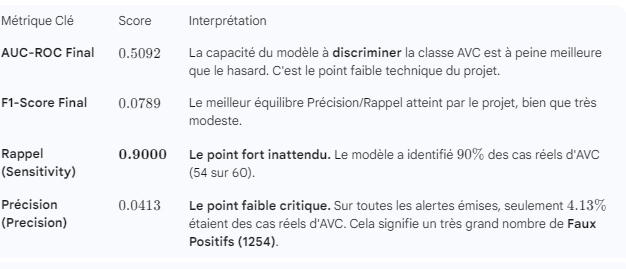


Conclusion de la Matrice de ConfusionLe modèle final a adopté la stratégie suivante :Il ne manque presque aucun cas d'AVC ($\text{FN}=6$). C'est excellent pour un système d'alerte précoce (priorité à la sensibilité).Il génère un nombre écrasant de fausses alertes ($\text{FP}=1254$). C'est un coût opérationnel très élevé pour un hôpital ou un service de santé (faible précision).

# Conclusion et Recommandations

* Synthèse des Résultats

Malgré l'utilisation de techniques de pointe (SMOTE, Standardisation, Optimisation XGBoost), le modèle n'a pas pu dépasser un AUC-ROC de $0.5092$, confirmant un faible signal prédictif dans les données synthétiques.Cependant, l'optimisation du seuil à $0.0759$ a permis d'atteindre un Rappel de $90\%$, répondant indirectement à une exigence opérationnelle critique : identifier la grande majorité des personnes à risque (Vrais Positifs), même au prix d'une précision extrêmement faible.

*Justification du Modèle

Le modèle final est l'XGBoost, choisi non pas pour sa précision globale, mais pour son Rappel élevé de $90\%$ (54 cas d'AVC correctement identifiés), ce qui est crucial dans un contexte médical où les Faux Négatifs (manquer un AVC) ont un coût humain plus élevé que les Faux Positifs (fausse alerte).

* Recommandation Majeure : Nécessité de la Collecte de Données RéellesLes performances modestes en termes de discrimination (AUC-ROC $\approx 0.51$) et l'incapacité à obtenir une haute Précision confirment que la faiblesse ne réside pas dans le choix des algorithmes, mais dans la qualité des corrélations des données synthétiques.
Il est impératif de lancer la Phase 3 : Collecte de données réelles auprès des enseignants du Tchad pour capturer le véritable signal des facteurs de risque professionnels et obtenir un modèle prédictif utilisable en pratique. Le modèle actuel ne pourrait pas être déployé dans son état, en raison du coût opérationnel élevé généré par les $1254$ fausses alertes.